In [566]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_distances
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# load data

In [567]:
df = pd.read_csv('/Users/connorhall/datasets/inst414/module 3 assignment/Public.csv',
                 usecols=['SPECIES', 'AIRPORT', 'STATE', 'FAAREGION'])
df = df.dropna()
df

,AIRPORT,STATE,FAAREGION,SPECIES
0,SACRAMENTO INTL,CA,AWP,Unknown bird - medium
1,DENVER INTL AIRPORT,CO,ANM,Unknown bird - medium
2,EPPLEY AIRFIELD,NE,ACE,Unknown bird - medium
3,WASHINGTON DULLES INTL ARPT,DC,AEA,Unknown bird - medium
4,LA GUARDIA ARPT,NY,AEA,Unknown bird - medium
...,...,...,...,...
339266,EVANSVILLE REGIONAL,IN,AGL,Chimney swift
339267,SEATTLE-TACOMA INTL,WA,ANM,Cedar waxwing
339268,CHICAGO O'HARE INTL ARPT,IL,AGL,Yellow-rumped warbler
339269,ROANOKE REGNL ARPT/WOODRUM FIELD,VA,AEA,European starling


# filter data

In [568]:
df['STATE'].values.unique()

<StringArray>
['CA', 'CO', 'NE', 'DC', 'NY', 'TX', 'MO', 'GA', 'LA', 'MI', 'IL', 'IN', 'OH',
 'NH', 'OR', 'PA', 'FL', 'MD', 'CT', 'RI', 'ID', 'MN', 'WA', 'NJ', 'HI', 'KY',
 'OK', 'IA', 'NC', 'VA', 'MA', 'UT', 'MS', 'TN', 'WV', 'AL', 'ME', 'AZ', 'AR',
 'AB', 'WI', 'PR', 'AK', 'NM', 'ND', 'NV', 'FN', 'ON', 'WY', 'SD', 'SC', 'MT',
 'KS', 'VI', 'DE', 'QC', 'VT', 'UM', 'BC', 'GU', 'AS', 'MH', 'MB', 'SK', 'MP',
 'NL', 'NS']
Length: 67, dtype: str

In [569]:
# remove locations outside lower 48 states
outlier_loc = ['AB', 'ON', 'PR', 'FN', 'QC', 'BC', 'AS', 'VI', 'AK',
                'UM', 'GU', 'MH', 'SK', 'NL', 'NS', 'MB', 'MP', 'HI']
df = df[~df['STATE'].isin(outlier_loc)]

# remove species with less than 100 collisions
df = df[df.groupby('SPECIES')['SPECIES'].transform('count') >= 100]
# remove airports with less than 100 collisions
df = df[df.groupby('AIRPORT')['AIRPORT'].transform('count') >= 100]

df = df[['SPECIES', 'AIRPORT']]

## find vague or invalid species and airport values

In [570]:
df['SPECIES'].sort_values().values.unique().tolist()

['American barn owl',
 'American coot',
 'American crow',
 'American golden-plover',
 'American goldfinch',
 'American kestrel',
 'American pipit',
 'American robin',
 'American wigeon',
 'American woodcock',
 'Bald eagle',
 'Bank swallow',
 'Barn swallow',
 'Big brown bat',
 'Black vulture',
 'Black-bellied plover',
 'Black-crowned night heron',
 'Black-tailed jackrabbit',
 'Black-tailed prairie dog',
 'Blackbirds',
 'Blackpoll warbler',
 'Boat-tailed grackle',
 'Brazilian free-tailed bat',
 "Brewer's blackbird",
 'Brown-headed cowbird',
 'Burrowing owl',
 'California gull',
 'Canada goose',
 'Cedar waxwing',
 'Chimney swift',
 'Chipping sparrow',
 'Cliff swallow',
 'Common grackle',
 'Common nighthawk',
 'Common yellowthroat',
 "Cooper's hawk",
 'Coyote',
 'Crows',
 'Dark-eyed junco',
 'Desert cottontail',
 'Double-crested cormorant',
 'Doves',
 'Ducks',
 'Ducks, geese, swans',
 'Dunlin',
 'Eastern cottontail',
 'Eastern kingbird',
 'Eastern meadowlark',
 'Eastern red bat',
 'Egrets'

In [571]:
df['AIRPORT'].sort_values().values.unique().tolist()

['ABERDEEN REGIONAL ARPT',
 'ABILENE REGIONAL ARPT',
 'ABRAHAM LINCOLN CAPITAL ARPT',
 'ADDISON AIRPORT',
 'AKRON-CANTON REGIONAL',
 'ALBANY INTL',
 'ALBUQUERQUE INTL SUNPORT',
 'ALLEGHENY COUNTY ARPT',
 'ASHEVILLE REGIONAL ARPT',
 'ASPEN-PITKIN COUNTY ARPT/SARDY FIELD',
 'ATLANTIC CITY INTL',
 'AUGUSTA REGIONAL ARPT AT BUSH FLD',
 'AUSTIN STRAUBEL INTL',
 'AUSTIN-BERGSTROM INTL',
 'BALTIMORE/WASH INTL THURGOOD MARSHAL ARPT',
 'BANGOR INTL',
 'BATON ROUGE METROPOLITAN, RYAN FIELD',
 'BELLINGHAM INTL',
 'BILL AND  HILLARY CLINTON NATL ARPT/ADAMS FIELD',
 'BILLINGS LOGAN INTL',
 'BIRMINGHAM-SHUTTLESWORTH INTL',
 'BISHOP INTL ARPT',
 'BISMARCK MUNICIPAL ARPT',
 'BLUE GRASS ARPT',
 'BOB HOPE ARPT',
 'BOCA RATON ARPT',
 'BOEING FIELD/KING COUNTY INTL ARPT',
 'BOISE AIR TERMINAL/GOWEN FIELD',
 'BOWMAN FIELD',
 'BRADLEY INTL',
 'BUFFALO-NIAGARA INTL',
 'BURKE LAKEFRONT',
 'BURLINGTON INTL',
 'CAMARILLO',
 'CAPE COD GATEWAY AIRPORT',
 'CAPITAL REGION INTL ARPT',
 'CECIL ARPT',
 'CENTENNIAL ARP

## remove values

In [572]:
# remove species values containing "unknown" or "perching birds"
df = df[~df['SPECIES'].str.contains('unknown|perching birds', case=False)]

# calculate # of collisions at each airport for each species

In [573]:
counts = pd.crosstab(df['SPECIES'], df['AIRPORT']).stack('AIRPORT')
counts

SPECIES                AIRPORT                     
American barn owl      ABERDEEN REGIONAL ARPT          0
                       ABILENE REGIONAL ARPT           0
                       ABRAHAM LINCOLN CAPITAL ARPT    0
                       ADDISON AIRPORT                 0
                       AKRON-CANTON REGIONAL           1
                                                      ..
Yellow-rumped warbler  WILMINGTON AIR PARK             0
                       WILMINGTON INTL                 3
                       WORCESTER REGIONAL              0
                       YAMPA VALLEY                    1
                       YEAGER ARPT                     0
Length: 45563, dtype: int64

## convert multiindex into separate columns

In [574]:
# get list of all species and airport values
species = counts.index.get_level_values('SPECIES').tolist()
airports = counts.index.get_level_values('AIRPORT').tolist()

counts_df = pd.DataFrame({'Species': species, 'Airport': airports})
# assign calculated airport count to a column
counts_df['Count'] = counts.values
counts_df

,Species,Airport,Count
0,American barn owl,ABERDEEN REGIONAL ARPT,0
1,American barn owl,ABILENE REGIONAL ARPT,0
2,American barn owl,ABRAHAM LINCOLN CAPITAL ARPT,0
3,American barn owl,ADDISON AIRPORT,0
4,American barn owl,AKRON-CANTON REGIONAL,1
...,...,...,...
45558,Yellow-rumped warbler,WILMINGTON AIR PARK,0
45559,Yellow-rumped warbler,WILMINGTON INTL,3
45560,Yellow-rumped warbler,WORCESTER REGIONAL,0
45561,Yellow-rumped warbler,YAMPA VALLEY,1


## create new dataframe 

In [575]:
# get lists of unique species and airport values
unique_sp = sorted(list(set(species)))
unique_air = sorted(list(set(airports)))

# create list of collision count lists
counts_list = []
# for each species
for sp in unique_sp:
    # select species from dataframe
    sp_filter = counts_df[counts_df['Species'] == sp]
    # get species' airport counts
    counts_list.append(sp_filter['Count'].tolist())
    
# create new dataframe
collisions_df = pd.DataFrame(counts_list, columns=unique_air, index=unique_sp)
collisions_df

,ABERDEEN REGIONAL ARPT,ABILENE REGIONAL ARPT,ABRAHAM LINCOLN CAPITAL ARPT,ADDISON AIRPORT,AKRON-CANTON REGIONAL,ALBANY INTL,ALBUQUERQUE INTL SUNPORT,ALLEGHENY COUNTY ARPT,ASHEVILLE REGIONAL ARPT,ASPEN-PITKIN COUNTY ARPT/SARDY FIELD,...,WICHITA DWIGHT D EISENHOWER NATL ARPT,WILKES-BARRE/SCRANTON INTL,WILL ROGERS WORLD ARPT,WILLIAM P HOBBY ARPT,WILLOW RUN ARPT,WILMINGTON AIR PARK,WILMINGTON INTL,WORCESTER REGIONAL,YAMPA VALLEY,YEAGER ARPT
American barn owl,0,0,0,0,1,0,1,0,1,0,...,0,0,3,14,0,0,0,0,0,0
American coot,1,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
American crow,0,0,1,2,1,8,0,1,4,5,...,1,2,0,2,0,0,0,1,0,20
American golden-plover,0,0,0,0,0,3,0,0,0,0,...,0,0,0,2,1,0,0,0,0,0
American goldfinch,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Woodchuck,0,0,0,0,0,6,0,1,1,0,...,0,1,0,0,1,0,0,0,0,0
Yellow warbler,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
Yellow-bellied sapsucker,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,1,1,0,0
Yellow-crowned night heron,0,0,0,0,0,0,0,0,0,0,...,0,0,0,10,0,0,0,0,0,0


## verify output

In [576]:
# compare each species' sum of collisions from counts_df and collisions_df
counts_1 = counts_df.groupby('Species')['Count'].sum().values.tolist()
counts_2 = collisions_df.sum(axis=1).values.tolist()
counts_1 == counts_2

True

# similarity assessment

## find species of interest

In [577]:
df['SPECIES'].value_counts().head(20)

SPECIES
Mourning dove         16135
Barn swallow          10367
Killdeer              10268
American kestrel       9507
Horned lark            8376
European starling      6483
Gulls                  6081
Eastern meadowlark     4868
Rock pigeon            4189
Red-tailed hawk        4051
Sparrows               3783
Cliff swallow          3207
Western meadowlark     2579
Ring-billed gull       2255
Herring gull           2059
American barn owl      1821
American robin         1815
Canada goose           1662
Microbats              1646
Chimney swift          1565
Name: count, dtype: int64

In [594]:
target_species = ['American kestrel', 'Horned lark', 'Herring gull']

## measure species similarity with cosine distance

In [ ]:
dist = cosine_distances
dataframes = []

for species in target_species:
    # get collision counts for target species
    target_species_collisions = collisions_df.loc[species]

    # generate distances from target species to others
    distances = dist(collisions_df, [target_species_collisions])[:,0]

    # create list of species and distances/scores
    query_distances = list(zip(collisions_df.index, distances))
    
    species_list = []
    score_list = []
    
    # sort list by distance/score
    for similar_species, similar_airport_score in sorted(query_distances, key=lambda x: x[1], reverse=False)[:10]:
        species_list.append(similar_species)
        score_list.append(similar_airport_score)
        
    dataframes.append(pd.DataFrame({'Species': species_list, 'Similarity score': score_list}))

In [597]:
# american kestrel
dataframes[0]

,Species,Similarity score
0,American kestrel,2.220446e-16
1,Barn swallow,3.289959e-01
2,Ring-billed gull,3.468422e-01
3,Short-eared owl,3.474042e-01
4,Mallard,3.500151e-01
5,European starling,3.557287e-01
6,Red-tailed hawk,3.594655e-01
7,American crow,3.776432e-01
8,Peregrine falcon,3.816527e-01
9,Song sparrow,4.022124e-01


In [598]:
# horned lark
dataframes[1]

,Species,Similarity score
0,Horned lark,0.000000
1,Gopher snake,0.031270
2,Desert cottontail,0.032333
3,White-tailed jackrabbit,0.033740
4,Lark bunting,0.039333
5,Black-tailed prairie dog,0.046197
6,Great horned owl,0.072481
7,Western meadowlark,0.078625
8,Eastern cottontail,0.153290
9,Cliff swallow,0.257799


In [599]:
# american herring gull
dataframes[2]

,Species,Similarity score
0,Herring gull,1.110223e-16
1,Great black-backed gull,3.372781e-02
2,Double-crested cormorant,1.112087e-01
3,Laughing gull,1.543961e-01
4,Semipalmated plover,1.648893e-01
5,Peregrine falcon,1.650072e-01
6,Black-crowned night heron,1.860487e-01
7,Northern flicker,2.119469e-01
8,Osprey,2.198504e-01
9,Wood duck,2.279663e-01


# clustering

## transformation

In [578]:
# hellinger transformation
hellinger_df = np.sqrt(collisions_df.div(collisions_df.sum(axis=1), axis=0))

In [579]:
hellinger_df

,ABERDEEN REGIONAL ARPT,ABILENE REGIONAL ARPT,ABRAHAM LINCOLN CAPITAL ARPT,ADDISON AIRPORT,AKRON-CANTON REGIONAL,ALBANY INTL,ALBUQUERQUE INTL SUNPORT,ALLEGHENY COUNTY ARPT,ASHEVILLE REGIONAL ARPT,ASPEN-PITKIN COUNTY ARPT/SARDY FIELD,...,WICHITA DWIGHT D EISENHOWER NATL ARPT,WILKES-BARRE/SCRANTON INTL,WILL ROGERS WORLD ARPT,WILLIAM P HOBBY ARPT,WILLOW RUN ARPT,WILMINGTON AIR PARK,WILMINGTON INTL,WORCESTER REGIONAL,YAMPA VALLEY,YEAGER ARPT
American barn owl,0.000000,0.0,0.000000,0.000000,0.023434,0.000000,0.023434,0.000000,0.023434,0.000000,...,0.000000,0.000000,0.040589,0.087682,0.000000,0.0,0.00000,0.000000,0.000000,0.000000
American coot,0.050125,0.0,0.050125,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.050125,0.000000,0.000000,0.0,0.00000,0.000000,0.000000,0.000000
American crow,0.000000,0.0,0.038547,0.054514,0.038547,0.109028,0.000000,0.038547,0.077094,0.086194,...,0.038547,0.054514,0.000000,0.054514,0.000000,0.0,0.00000,0.038547,0.000000,0.172388
American golden-plover,0.000000,0.0,0.000000,0.000000,0.000000,0.100504,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.082061,0.058026,0.0,0.00000,0.000000,0.000000,0.000000
American goldfinch,0.000000,0.0,0.082479,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Woodchuck,0.000000,0.0,0.000000,0.000000,0.000000,0.168630,0.000000,0.068843,0.068843,0.000000,...,0.000000,0.068843,0.000000,0.000000,0.068843,0.0,0.00000,0.000000,0.000000,0.000000
Yellow warbler,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.099504,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,0.000000,0.000000
Yellow-bellied sapsucker,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.091670,0.000000,0.000000,0.000000,0.0,0.09167,0.091670,0.000000,0.000000
Yellow-crowned night heron,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.266312,0.000000,0.0,0.00000,0.000000,0.000000,0.000000


### verify variance & outliers minimized

In [580]:
print(hellinger_df.values.min())
print(hellinger_df.values.max())

0.0
0.9118672225175284


## dimensionality reduction

### quantity of zeros before reduction

In [581]:
collision_vals = []
# iterate through each species' values
for val_list in hellinger_df.values.tolist():
    # add values to list
    collision_vals += val_list

pd.DataFrame(collision_vals).value_counts()

0       
0.000000    31826
0.064957       83
0.049814       80
0.093250       75
0.040324       72
            ...  
0.266312        1
0.211341        1
0.341504        1
0.268254        1
0.131794        1
Name: count, Length: 2662, dtype: int64

In [582]:
# percentage of values that are 0
int(pd.DataFrame(collision_vals).value_counts()[0]) / (len(hellinger_df.index) * len(hellinger_df.columns))

0.6985053661962557

### pca

In [583]:
# PCA dimensionality reduction
pca = PCA(n_components=0.95)
pca_data = pca.fit_transform(hellinger_df)

In [584]:
pca_data

array([[ 0.23532856, -0.21060607,  0.18407222, ...,  0.03424284,
        -0.02685515, -0.00590069],
       [ 0.19447757, -0.21875972,  0.01586478, ...,  0.01385309,
         0.02507145,  0.0038618 ],
       [-0.11362916, -0.0840985 , -0.11329901, ...,  0.04866704,
         0.09630884, -0.00880883],
       ...,
       [-0.45742164, -0.14773156,  0.05994883, ..., -0.03296611,
        -0.03758742, -0.02710642],
       [-0.01009278,  0.37648906,  0.39803037, ..., -0.06366777,
         0.03308953,  0.01216445],
       [-0.27663441, -0.08035683,  0.12351225, ...,  0.05262129,
        -0.02215175, -0.03713657]], shape=(161, 84))

### quanity of zeros after reduction

In [585]:
collision_pca_vals = []
# iterate through each species' values
for val_list in pd.DataFrame(pca_data).values.tolist():
    # add values to list
    collision_pca_vals += val_list

pd.DataFrame(collision_pca_vals)[pd.DataFrame(collision_pca_vals)[0] == 0]

,0


# kmeans clustering

### inertia values by k

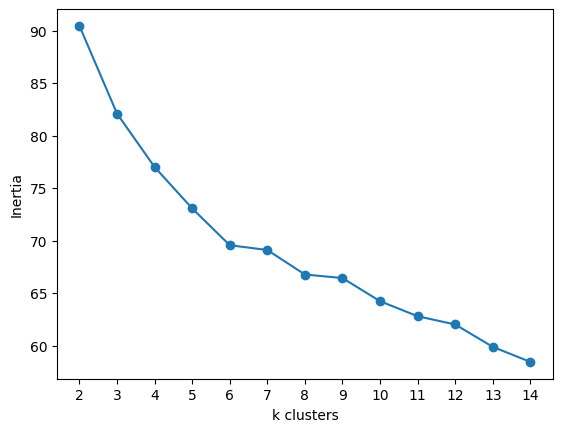

In [586]:
intertia_values = []
for k in range(2, 15):
    cluster_model = KMeans(n_clusters=k)
    cluster_model.fit(pca_data)
    intertia_values.append(cluster_model.inertia_)

plt.plot(range(2, 15), intertia_values, marker='o')
plt.xticks(range(2, 15))
plt.xlabel('k clusters')
plt.ylabel('Inertia')
plt.show()

### kmeans clustering at k=7

In [630]:
cluster_model = KMeans(n_clusters=7)
clusters = cluster_model.fit_predict(pca_data)

### cluster sizes

In [631]:
pd.DataFrame(clusters).value_counts()

0
1    55
6    28
4    26
2    16
0    15
5    14
3     7
Name: count, dtype: int64

### assign labels

In [633]:
labeled_df = collisions_df.copy()
labeled_df['Cluster'] = clusters
labeled_df

,ABERDEEN REGIONAL ARPT,ABILENE REGIONAL ARPT,ABRAHAM LINCOLN CAPITAL ARPT,ADDISON AIRPORT,AKRON-CANTON REGIONAL,ALBANY INTL,ALBUQUERQUE INTL SUNPORT,ALLEGHENY COUNTY ARPT,ASHEVILLE REGIONAL ARPT,ASPEN-PITKIN COUNTY ARPT/SARDY FIELD,...,WILKES-BARRE/SCRANTON INTL,WILL ROGERS WORLD ARPT,WILLIAM P HOBBY ARPT,WILLOW RUN ARPT,WILMINGTON AIR PARK,WILMINGTON INTL,WORCESTER REGIONAL,YAMPA VALLEY,YEAGER ARPT,Cluster
American barn owl,0,0,0,0,1,0,1,0,1,0,...,0,3,14,0,0,0,0,0,0,4
American coot,1,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,4
American crow,0,0,1,2,1,8,0,1,4,5,...,2,0,2,0,0,0,1,0,20,1
American golden-plover,0,0,0,0,0,3,0,0,0,0,...,0,0,2,1,0,0,0,0,0,6
American goldfinch,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Woodchuck,0,0,0,0,0,6,0,1,1,0,...,1,0,0,1,0,0,0,0,0,1
Yellow warbler,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,4
Yellow-bellied sapsucker,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,1,0,0,6
Yellow-crowned night heron,0,0,0,0,0,0,0,0,0,0,...,0,0,10,0,0,0,0,0,0,5


### sample species from each cluster

In [635]:
# get # of items in smallest cluster
min_cluster_size = pd.DataFrame(clusters).value_counts().min()
# sample species from each cluster
samples = labeled_df[['Cluster']].groupby('Cluster').sample(min_cluster_size)

for cluster in samples['Cluster'].unique().tolist():
    print(f'Cluster {cluster}: {samples[samples['Cluster'] == cluster].index.tolist()}\n')

Cluster 0: ['Great horned owl', 'Lark bunting', 'Burrowing owl', 'White-tailed jackrabbit', 'Mountain bluebird', 'Eurasian collared dove', 'Black-tailed prairie dog']

Cluster 1: ['Raccoon', 'Common nighthawk', 'Rock pigeon', 'American goldfinch', 'Purple martin', 'American crow', 'Common grackle']

Cluster 2: ['Great black-backed gull', 'Dunlin', 'Northern harrier', 'Osprey', 'Least sandpiper', 'Laughing gull', 'White-headed gull complex']

Cluster 3: ['White-winged dove', 'Scissor-tailed flycatcher', 'Grackles', 'Great-tailed grackle', 'Upland sandpiper', "Franklin's gull", 'Meadowlarks']

Cluster 4: ['American pipit', 'Green-winged teal', 'Ducks, geese, swans', "Brewer's blackbird", 'Yellow warbler', 'American coot', 'White-throated swift']

Cluster 5: ['Great egret', 'Sandhill crane', 'Western cattle egret', 'Doves', 'Evening bat', 'Boat-tailed grackle', 'Egrets']

Cluster 6: ['Ruby-crowned kinglet', 'Blackpoll warbler', "Swainson's thrush", 'American woodcock', 'Gray catbird', 'Ye

# verify similarity assessment with cluster labels

## repeat similarity calculation, add cluster labels to dataframes

In [ ]:
dataframes_clustered = []

for species in target_species:
    # get collision counts for target species
    target_species_collisions = collisions_df.loc[species]

    # generate distances from target species to others
    distances = dist(collisions_df, [target_species_collisions])[:,0]

    # create list of species and distances/scores
    query_distances = list(zip(collisions_df.index, distances))

    species_list = []
    score_list = []
    cluster_list = []
    
    # sort list by distance/score
    for similar_species, similar_airport_score in sorted(query_distances, key=lambda x: x[1], reverse=False):
        species_list.append(similar_species)
        score_list.append(similar_airport_score)
        # get species cluster
        cluster = int(labeled_df.loc[similar_species][-1:].values[0])
        cluster_list.append(cluster)
        
    dataframes_clustered.append(pd.DataFrame({'Species': species_list, 'Similarity score': score_list, 'Cluster': cluster_list}))

## match similar species' clusters to target species' cluster

In [654]:
dataframes_corrected = []

for dfc in dataframes_clustered:
    # get cluster of target species
    target_sp_cluster = dfc.iloc[0]['Cluster']
    # select species in same cluster
    dfc = dfc[dfc['Cluster'] == target_sp_cluster]
    # add to list of corrected dataframes
    dataframes_corrected.append(dfc)

### function to output dataframes

In [ ]:
def output_similar_sp(df_num):
    # select dataframe from list
    df = dataframes_corrected[df_num]
    
    # return top 10 species if possible
    if len(df) >= 10:
        return df.head(10)
    
    # return all species otherwise
    else:
        return df.head(len(df))

In [660]:
output_similar_sp(0)

,Species,Similarity score,Cluster
0,American kestrel,2.220446e-16,1
1,Barn swallow,3.289959e-01,1
2,Ring-billed gull,3.468422e-01,1
3,Short-eared owl,3.474042e-01,1
4,Mallard,3.500151e-01,1
5,European starling,3.557287e-01,1
6,Red-tailed hawk,3.594655e-01,1
7,American crow,3.776432e-01,1
10,Canada goose,4.045116e-01,1
13,Common grackle,4.159924e-01,1


In [661]:
output_similar_sp(1)

,Species,Similarity score,Cluster
0,Horned lark,0.000000,0
1,Gopher snake,0.031270,0
2,Desert cottontail,0.032333,0
3,White-tailed jackrabbit,0.033740,0
4,Lark bunting,0.039333,0
5,Black-tailed prairie dog,0.046197,0
6,Great horned owl,0.072481,0
7,Western meadowlark,0.078625,0
10,Black-tailed jackrabbit,0.316159,0
11,Vesper sparrow,0.343400,0


In [662]:
output_similar_sp(2)

,Species,Similarity score,Cluster
0,Herring gull,1.110223e-16,2
1,Great black-backed gull,3.372781e-02,2
2,Double-crested cormorant,1.112087e-01,2
3,Laughing gull,1.543961e-01,2
4,Semipalmated plover,1.648893e-01,2
5,Peregrine falcon,1.650072e-01,2
6,Black-crowned night heron,1.860487e-01,2
8,Osprey,2.198504e-01,2
10,Snow bunting,2.331591e-01,2
13,Snowy owl,3.059620e-01,2
